In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import shap

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('healthcare-dataset-stroke-data.csv')
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## EDA

In [5]:
data.shape

(5110, 12)

In [6]:
data.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [8]:
data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

In [9]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [10]:
data.drop('id',axis=1, inplace=True)

In [11]:
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


<Axes: xlabel='stroke', ylabel='count'>

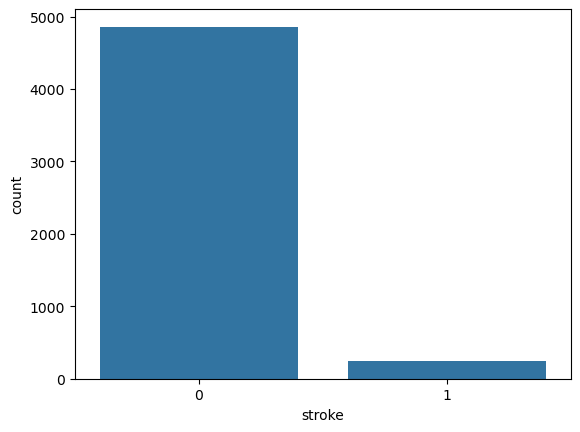

In [12]:
sns.countplot(x='stroke', data=data)

In [13]:
data['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='stroke'>

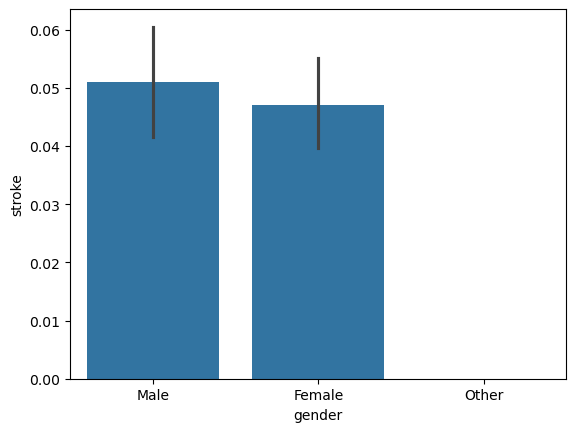

In [14]:
sns.barplot(x='gender', y='stroke', data=data)

In [15]:
data['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [16]:
data[data['gender']=='Other']

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [17]:
data.drop(data[data['gender']=='Other'].index, inplace=True)

In [18]:
data['gender'].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='stroke'>

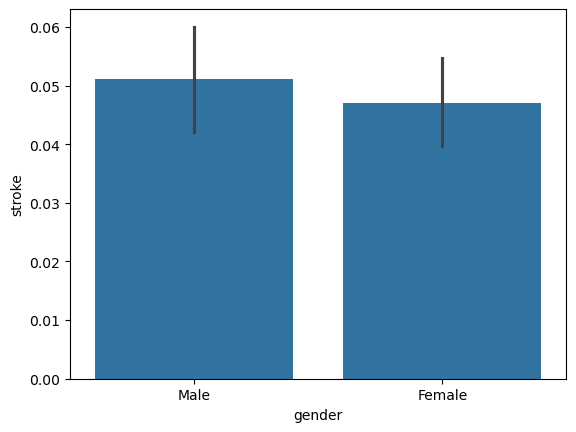

In [19]:
sns.barplot(x='gender', y='stroke', data=data)

In [20]:
data = pd.get_dummies(data, drop_first=True,dtype=int)

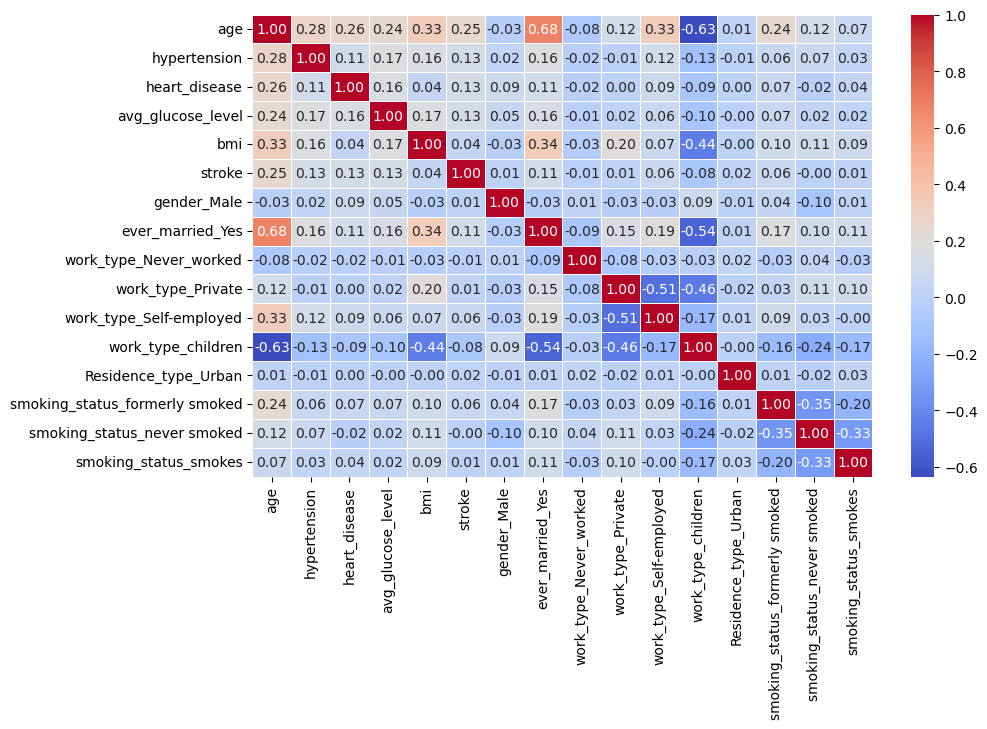

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(),annot=True,        # Show correlation values
    cmap="coolwarm",   # Color map
    fmt=".2f",         # Format numbers to 2 decimal places
    linewidths=0.5)

plt.show()

In [22]:
data.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,1,1,0,1,0,0,1,1,0,0
1,61.0,0,0,202.21,28.893237,1,0,1,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.500000,1,1,1,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.400000,1,0,1,0,1,0,0,1,0,0,1
4,79.0,1,0,174.12,24.000000,1,0,1,0,0,1,0,0,0,1,0


In [23]:
data.shape

(5109, 16)

In [24]:
data.columns

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')

In [25]:
data = data[['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'gender_Male', 'ever_married_Yes', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes', 'stroke']]

In [26]:
data

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,67.0,0,1,228.69,36.600000,1,1,0,1,0,0,1,1,0,0,1
1,61.0,0,0,202.21,28.893237,0,1,0,0,1,0,0,0,1,0,1
2,80.0,0,1,105.92,32.500000,1,1,0,1,0,0,0,0,1,0,1
3,49.0,0,0,171.23,34.400000,0,1,0,1,0,0,1,0,0,1,1
4,79.0,1,0,174.12,24.000000,0,1,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,80.0,1,0,83.75,28.893237,0,1,0,1,0,0,1,0,1,0,0
5106,81.0,0,0,125.20,40.000000,0,1,0,0,1,0,1,0,1,0,0
5107,35.0,0,0,82.99,30.600000,0,1,0,0,1,0,0,0,1,0,0
5108,51.0,0,0,166.29,25.600000,1,1,0,1,0,0,0,1,0,0,0


In [27]:
data['stroke'].value_counts()

stroke
0    4860
1     249
Name: count, dtype: int64

### Splitting data into training and test sets

In [28]:
x = data.iloc[:,:-1]
x[:10]

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,1,0,1,0,0,1,1,0,0
1,61.0,0,0,202.21,28.893237,0,1,0,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.500000,1,1,0,1,0,0,0,0,1,0
3,49.0,0,0,171.23,34.400000,0,1,0,1,0,0,1,0,0,1
4,79.0,1,0,174.12,24.000000,0,1,0,0,1,0,0,0,1,0
5,81.0,0,0,186.21,29.000000,1,1,0,1,0,0,1,1,0,0
6,74.0,1,1,70.09,27.400000,1,1,0,1,0,0,0,0,1,0
7,69.0,0,0,94.39,22.800000,0,0,0,1,0,0,1,0,1,0
8,59.0,0,0,76.15,28.893237,0,1,0,1,0,0,0,0,0,0
9,78.0,0,0,58.57,24.200000,0,1,0,1,0,0,1,0,0,0


In [29]:
y = data.iloc[:,-1:]
y[:10]

,stroke
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size=0.2, random_state=10)

In [32]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4087, 15)
(1022, 15)
(4087, 1)
(1022, 1)


### Normalization

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)

x_test = sc.transform(x_test)

## Training models

### Logistic regression

In [33]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [34]:
lr.fit(x_train, y_train)

LogisticRegression()

In [35]:
y_pred = lr.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [36]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [37]:
lr_cm = confusion_matrix(y_test, y_pred)
print(lr_cm)

[[960   0]
 [ 62   0]]


In [38]:
lr_cr = classification_report(y_test, y_pred)
print(lr_cr)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [39]:
lr_accuracy = accuracy_score(y_test, y_pred)
lr_accuracy

0.9393346379647749

### ROC Curve

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [41]:
roc_auc = auc(fpr, tpr)

In [42]:
roc_auc

np.float64(0.5)

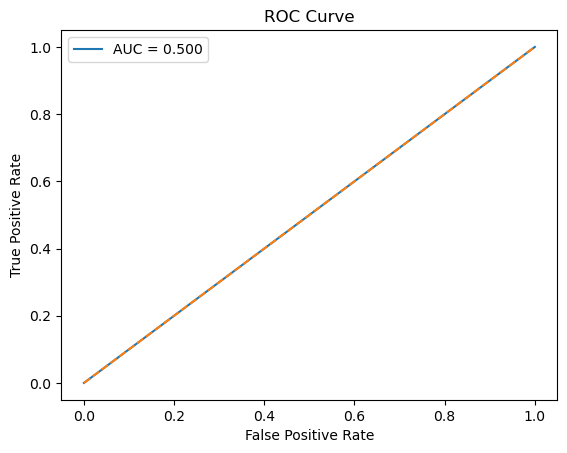

In [43]:
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## KNN Model

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [46]:
y_pred = knn.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [47]:
knn_cm = confusion_matrix(y_test, y_pred)
print(knn_cm)

[[955   5]
 [ 62   0]]


In [48]:
knn_cr = classification_report(y_test, y_pred)
print(knn_cr)

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.93      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.93      0.91      1022



In [49]:
knn_accuracy = accuracy_score(y_test, y_pred)
knn_accuracy

0.9344422700587084

### ROC Curve

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [51]:
roc_auc = auc(fpr, tpr)

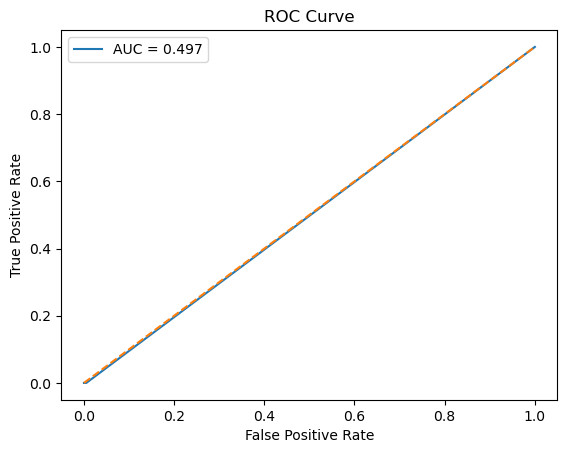

In [52]:
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Kernel SVM

In [53]:
from sklearn.svm import SVC

In [54]:
svm = SVC(kernel='rbf', random_state=32)

In [55]:
svm.fit(x_train, y_train)

SVC(random_state=32)

In [56]:
y_pred = svm.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [57]:
svm_cm = confusion_matrix(y_test, y_pred)
print(svm_cm)

[[960   0]
 [ 62   0]]


In [58]:
svm_cr = classification_report(y_test, y_pred)
print(svm_cr)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [59]:
svm_accuracy = accuracy_score(y_test, y_pred)
svm_accuracy

0.9393346379647749

### Roc curve

In [60]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [61]:
roc_auc = auc(fpr, tpr)

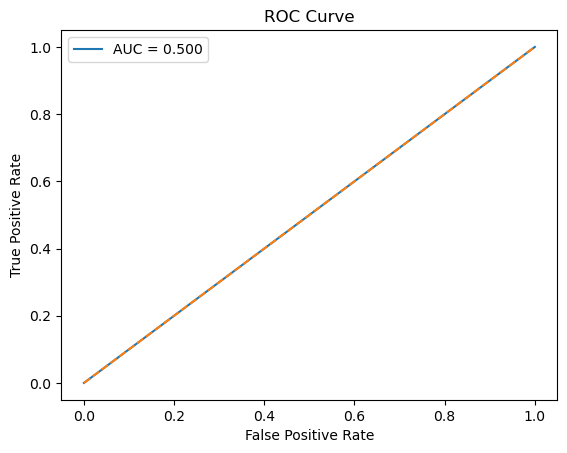

In [62]:
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Naive Bayes

In [63]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [64]:
nb.fit(x_train, y_train)

GaussianNB()

In [65]:
y_pred = nb.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 1, 1])

In [66]:
nb_cm = confusion_matrix(y_test, y_pred)
print(nb_cm)

[[508 452]
 [  4  58]]


In [67]:
nb_cr = classification_report(y_test, y_pred)
print(nb_cr)

              precision    recall  f1-score   support

           0       0.99      0.53      0.69       960
           1       0.11      0.94      0.20        62

    accuracy                           0.55      1022
   macro avg       0.55      0.73      0.45      1022
weighted avg       0.94      0.55      0.66      1022



In [68]:
nb_accuracy = accuracy_score(y_test, y_pred)
nb_accuracy

0.5538160469667319

In [69]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [70]:
roc_auc = auc(fpr, tpr)

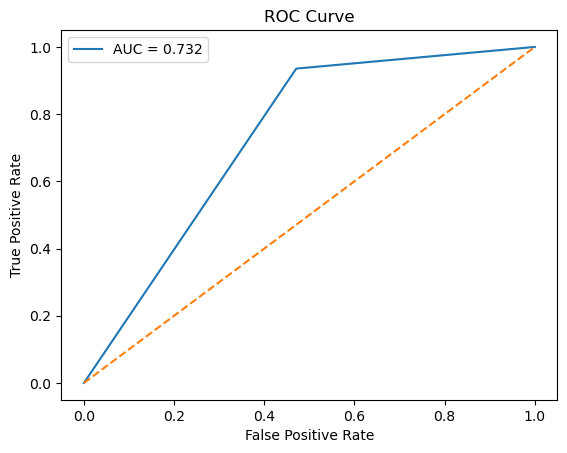

In [71]:
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
dt.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [73]:
y_pred = dt.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [74]:
dt_cm = confusion_matrix(y_test, y_pred)
print(dt_cm)

[[921  39]
 [ 57   5]]


In [75]:
dt_cr = classification_report(y_test, y_pred)
print(dt_cr)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       960
           1       0.11      0.08      0.09        62

    accuracy                           0.91      1022
   macro avg       0.53      0.52      0.52      1022
weighted avg       0.89      0.91      0.90      1022



In [76]:
dt_accuracy = accuracy_score(y_test, y_pred)
dt_accuracy

0.9060665362035225

In [77]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [78]:
roc_auc = auc(fpr, tpr)

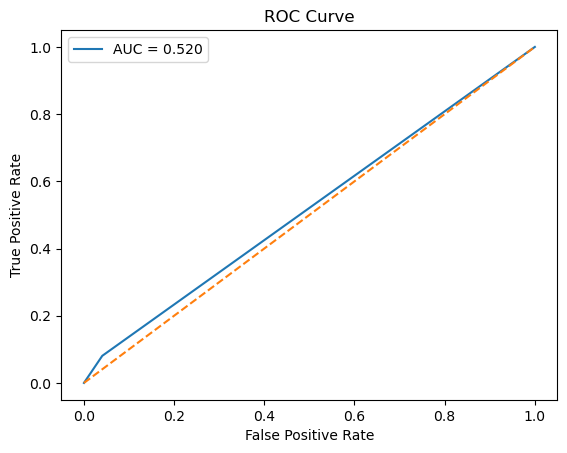

In [79]:
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Random Forest Model

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=4, min_samples_leaf=2, random_state=42, class_weight='balanced')

In [81]:
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=4,
                       n_estimators=300, random_state=42)

In [82]:
y_pred = rf.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [83]:
rf_cm = confusion_matrix(y_test, y_pred)
print(rf_cm)

[[917  43]
 [ 52  10]]


In [84]:
rf_cr = classification_report(y_test, y_pred)
print(rf_cr)

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       960
           1       0.19      0.16      0.17        62

    accuracy                           0.91      1022
   macro avg       0.57      0.56      0.56      1022
weighted avg       0.90      0.91      0.90      1022



In [85]:
rf_accuracy = accuracy_score(y_test, y_pred)
rf_accuracy

0.9070450097847358

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

In [87]:
roc_auc = auc(fpr, tpr)

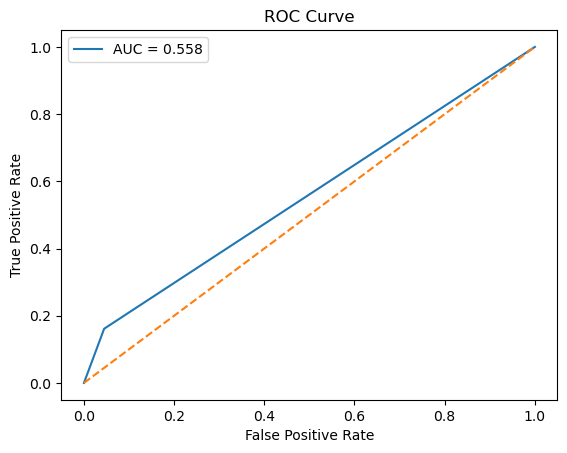

In [88]:
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [89]:
print(f"Logistic Regression: {lr_accuracy * 100:.2f}")
print(f"KNN Model          : {knn_accuracy * 100:.2f}")
print(f"SVM Model          : {svm_accuracy * 100:.2f}")
print(f"Naive Bayes        : {nb_accuracy * 100:.2f}")
print(f"Decision Tree      : {dt_accuracy * 100:.2f}")
print(f"Random Forest      : {rf_accuracy * 100:.2f}")

Logistic Regression: 93.93
KNN Model          : 93.44
SVM Model          : 93.93
Naive Bayes        : 55.38
Decision Tree      : 90.61
Random Forest      : 90.70


### Applying k-Fold Cross Validation on RF model

In [90]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = rf, X = x_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 92.51 %
Standard Deviation: 1.67 %


In [91]:
rf.feature_importances_

array([4.27337030e-01, 4.15629776e-02, 3.12629107e-02, 1.58128991e-01,
       1.49106373e-01, 1.83169966e-02, 3.94141905e-02, 1.18945647e-04,
       1.71411877e-02, 1.96554288e-02, 2.45647080e-02, 2.07404968e-02,
       1.74366881e-02, 2.16897239e-02, 1.35233517e-02])

In [92]:
explainer = shap.TreeExplainer(rf)

In [93]:
shap_values = explainer.shap_values(x_test)

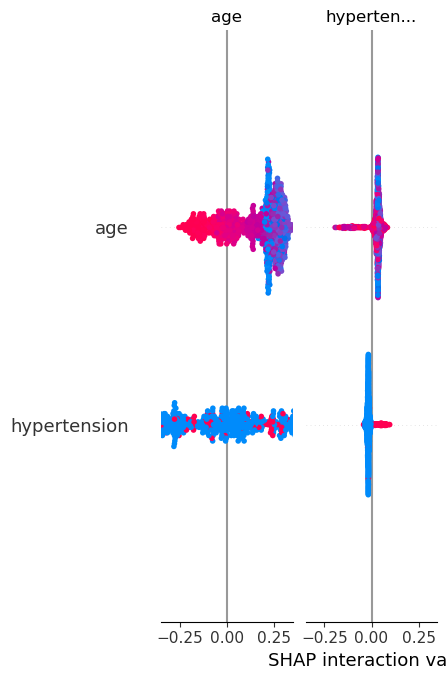

In [94]:
shap.summary_plot(shap_values, x_test)

In [95]:
import pickle

In [96]:
with open('stroke_model', 'wb') as file:
    pickle.dump(rf, file)

In [97]:
feature_list = list(data.columns)
print(feature_list)

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'stroke']


In [98]:
with open('stroke_feature_list', 'wb') as file:
    pickle.dump(feature_list, file)